# Online Review Sentiment Analysis (Flipkart / Twitter)
### NLP & Sentiment Analysis — Class Demo

This notebook walks through the full pipeline used in the assignment:
1. Load the dataset
2. Text preprocessing (tokenization, stopword removal, TF-IDF)
3. Train/test split
4. Build and evaluate classification models
5. Compare models
6. Visualize sentiment trends

All data here is **synthetic**, generated for teaching purposes.

In [1]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'DejaVu Serif'
print("Libraries ready.")

Libraries ready.


In [2]:
from google.colab import drive

drive.mount('/content/drive')

import os

folder = '/content/drive/MyDrive/UIU_Project'

print(os.listdir(folder))

Mounted at /content/drive
['synthetic_online_reviews_sentiment_final.xlsx', 'synthetic_predictive_analytics_dataset_1_5x.xlsx', 'synthetic_recommendation_system_dataset_1_5x.xlsx']


In [3]:
df = pd.read_excel('/content/drive/MyDrive/UIU_Project/synthetic_online_reviews_sentiment_final.xlsx', parse_dates=['date'])
print(df.shape)
df.head()

(1000, 7)


,review_id,review_text,product,sentiment,source,date,rating
0,100001,"So far, the Portable SSD has been okay for my ...",Portable SSD,Neutral,Daraz,2026-03-23,2
1,100002,This Foldable Laptop Stand has made my daily r...,Foldable Laptop Stand,Positive,YouTube Comments,2026-01-26,2
2,100003,After using this Wireless Charger Stand for se...,Wireless Charger Stand,Positive,Amazon,2026-03-13,5
3,100004,The Noise Cancelling Headphones looked promisi...,Noise Cancelling Headphones,Negative,Reddit,2026-08-13,3
4,100005,"The Portable SSD has some useful features, but...",Portable SSD,Neutral,YouTube Comments,2026-09-12,5


## 1. Load the dataset

In [4]:
print(df['sentiment'].value_counts())
print()
print(df['source'].value_counts())

sentiment
Positive    398
Negative    336
Neutral     266
Name: count, dtype: int64

source
Amazon              357
Daraz               318
Reddit              188
YouTube Comments    137
Name: count, dtype: int64


## 2. Text preprocessing

Three standard steps before modeling:
- **Tokenization** — split text into individual words
- **Stopword removal** — drop common words that carry little meaning ("the", "is", "and"...)
- **TF-IDF** — turn cleaned text into numeric features that weigh rare, informative words more heavily than common ones

In [5]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|@\w+|#', '', text)          # remove URLs, mentions, hashtag symbol
    text = text.translate(str.maketrans('', '', string.punctuation))  # remove punctuation
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t.isalpha() and t not in stop_words]
    return ' '.join(tokens)

df['clean_text'] = df['review_text'].apply(clean_text)
df[['review_text', 'clean_text']].head(8)

,review_text,clean_text
0,"So far, the Portable SSD has been okay for my ...",far portable ssd okay needs product usable sma...
1,This Foldable Laptop Stand has made my daily r...,foldable laptop stand made daily routine easie...
2,After using this Wireless Charger Stand for se...,using wireless charger stand several days sati...
3,The Noise Cancelling Headphones looked promisi...,noise cancelling headphones looked promising a...
4,"The Portable SSD has some useful features, but...",portable ssd useful features exceptional resul...
5,The Electric Kettle works exactly as described...,electric kettle works exactly described materi...
6,The Smart LED Bulb has been a great purchase. ...,smart led bulb great purchase performance cons...
7,I did not expect this level of quality from th...,expect level quality usbc hub battery lasts lo...


In [6]:
# TF-IDF vectorization
tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1,2))
X = tfidf.fit_transform(df['clean_text'])
y = df['sentiment']

print("TF-IDF matrix shape:", X.shape)
print("Sample vocabulary:", list(tfidf.vocabulary_.keys())[:15])

TF-IDF matrix shape: (1000, 1936)
Sample vocabulary: ['far', 'portable', 'ssd', 'okay', 'needs', 'product', 'usable', 'small', 'inconveniences', 'item', 'matched', 'listing', 'details', 'would', 'describe']


## 3. Train/test split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Train size:", X_train.shape[0], " Test size:", X_test.shape[0])

Train size: 800  Test size: 200


## 4. Model selection and implementation

We train three common text-classification models and compare them:
- **Logistic Regression** — a strong, fast linear baseline
- **Multinomial Naive Bayes** — a classic, very fast text-classification model
- **Linear SVM** — often the strongest linear model for TF-IDF features

In [8]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Multinomial Naive Bayes": MultinomialNB(),
    "Linear SVM": LinearSVC(),
}

trained = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    trained[name] = model
    print(f"Trained: {name}")

Trained: Logistic Regression
Trained: Multinomial Naive Bayes
Trained: Linear SVM


## 5. Evaluation and model comparison

In [9]:
results = []
for name, model in trained.items():
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, preds, average='weighted', zero_division=0)
    results.append({"Model": name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1-score": f1})

results_df = pd.DataFrame(results).sort_values("F1-score", ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,1.0,1.0,1.0,1.0
1,Multinomial Naive Bayes,1.0,1.0,1.0,1.0
2,Linear SVM,1.0,1.0,1.0,1.0


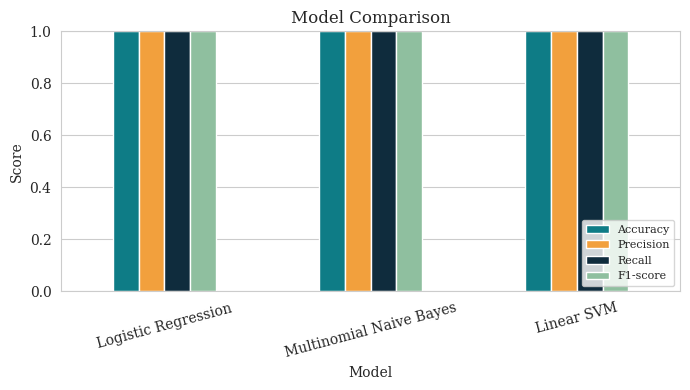

In [10]:
fig, ax = plt.subplots(figsize=(7,4))
results_df.set_index("Model")[["Accuracy","Precision","Recall","F1-score"]].plot.bar(ax=ax, color=['#0E7C86','#F2A03D','#0F2C3D','#8FBF9F'])
plt.title("Model Comparison")
plt.ylabel("Score")
plt.ylim(0,1)
plt.xticks(rotation=15)
plt.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

Best model: Logistic Regression

              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        67
     Neutral       1.00      1.00      1.00        53
    Positive       1.00      1.00      1.00        80

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



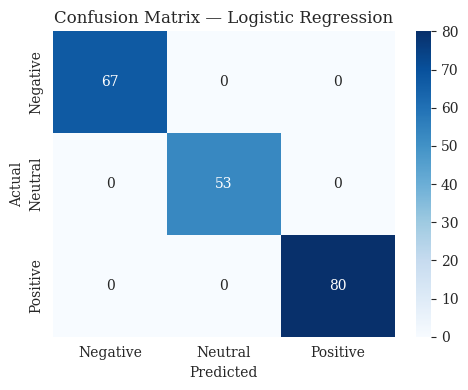

In [11]:
best_name = results_df.iloc[0]["Model"]
best_model = trained[best_name]
preds = best_model.predict(X_test)

print(f"Best model: {best_name}\n")
print(classification_report(y_test, preds, zero_division=0))

cm = confusion_matrix(y_test, preds, labels=best_model.classes_)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=best_model.classes_, yticklabels=best_model.classes_)
plt.title(f"Confusion Matrix — {best_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## 6. Visualizing sentiment trends

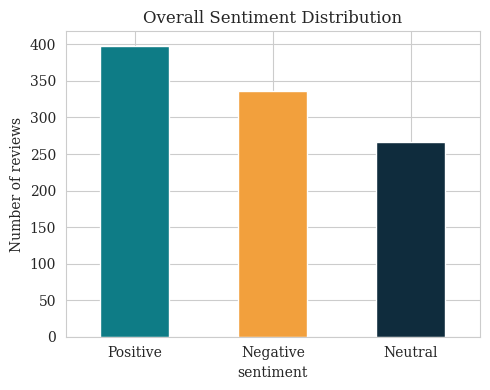

In [12]:
sent_counts = df['sentiment'].value_counts()
plt.figure(figsize=(5,4))
sent_counts.plot.bar(color=['#0E7C86','#F2A03D','#0F2C3D'])
plt.title("Overall Sentiment Distribution")
plt.ylabel("Number of reviews")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

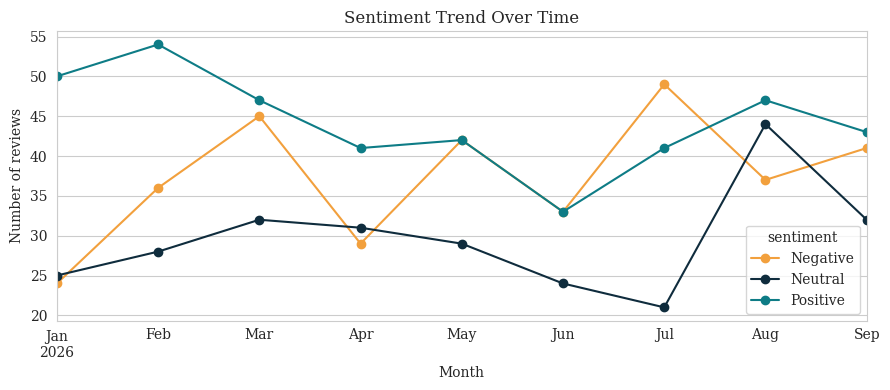

In [13]:
monthly = df.set_index('date').groupby([pd.Grouper(freq='ME'), 'sentiment']).size().unstack(fill_value=0)
monthly.plot(figsize=(9,4), marker='o', color=['#F2A03D','#0F2C3D','#0E7C86'])
plt.title("Sentiment Trend Over Time")
plt.ylabel("Number of reviews")
plt.xlabel("Month")
plt.tight_layout()
plt.show()

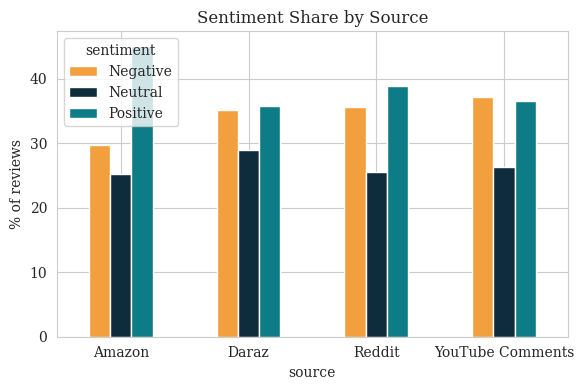

In [14]:
source_sentiment = pd.crosstab(df['source'], df['sentiment'], normalize='index') * 100
source_sentiment.plot.bar(figsize=(6,4), color=['#F2A03D','#0F2C3D','#0E7C86'])
plt.title("Sentiment Share by Source")
plt.ylabel("% of reviews")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 7. Result interpretation (discussion prompts for class)

- Which model performed best on F1-score, and why might that be, given how TF-IDF features behave?
- Look at the confusion matrix: which sentiment class is most often confused with another? Why might that be, given the templates used?
- What does the sentiment trend chart suggest about how opinion is spread across the year?
- Do Flipkart reviews and Twitter posts show different sentiment patterns? What might explain that?

These are exactly the kinds of questions the assignment's **Result Interpretation and Report** section asks students to answer.